In [ ]:
import os
import random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/Datasets/isic
!ls /content/drive/MyDrive/Datasets/pets

!cp -r /content/drive/MyDrive/Datasets/isic /content/
!cp -r /content/drive/MyDrive/Datasets/pets /content/

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
test  train
test  train


In [ ]:
class ISICDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        seed = random.randint(0, 2**32)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)

        mask = (mask > 0).float()

        return image, mask

class OxfordPetDataset(Dataset):

    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):

        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.images = []
        self.masks = []

        for img in sorted(os.listdir(images_dir)):

            mask_name = img.replace(".jpg", ".png")
            mask_path = os.path.join(masks_dir, mask_name)

            if os.path.exists(mask_path):

                self.images.append(img)
                self.masks.append(mask_name)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        seed = random.randint(0, 2**32)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        mask = np.array(mask)

        mask = (mask == 1).astype("float32")

        mask = torch.tensor(mask).unsqueeze(0)

        mask = torch.nn.functional.interpolate(
            mask.unsqueeze(0),
            size=(256,256),
            mode="nearest"
        ).squeeze(0)

        return image, mask

class DeepGlobeDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        seed = random.randint(0, 2**32)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)

        # segmentation binaire : forest vs reste
        mask = (mask == 4).float()

        return image, mask

In [ ]:
########################################
# CONFIGURATION
########################################

# dataset à utiliser
# "isic"
# "pets"
# "deepglobe"

DATASET = "isic"

# augmentation
# "baseline"
# "flip"
# "flip_rotation"
# "full_aug"

AUGMENTATION_CONFIG = "full_aug"

# taille du train set
TRAIN_SIZE = 0.8  #pourcentage utilisation du dataset

In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

########################################
# TRANSFORMS
########################################

if AUGMENTATION_CONFIG == "baseline":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "flip":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "flip_rotation":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "full_aug":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(25),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

else:
    raise ValueError("Unknown augmentation config")


mask_transform = transforms.Compose([
    transforms.Resize((256,256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

print("Using augmentation:", AUGMENTATION_CONFIG)

Using augmentation: full_aug


In [ ]:
########################################
# SELECT DATASET CLASS
########################################

if DATASET == "isic":
    DatasetClass = ISICDataset

elif DATASET == "pets":
    DatasetClass = OxfordPetDataset

elif DATASET == "deepglobe":
    DatasetClass = DeepGlobeDataset

else:
    raise ValueError("Unknown dataset")

########################################
# DATASET SELECTION
########################################

if DATASET == "isic":

    train_images = "/content/isic/train/images"
    train_masks = "/content/isic/train/masks"
    test_images = "/content/isic/test/images"
    test_masks = "/content/isic/test/masks"

elif DATASET == "pets":

    train_images = "/content/pets/train/images"
    train_masks = "/content/pets/train/masks"
    test_images = "/content/pets/test/images"
    test_masks = "/content/pets/test/masks"

elif DATASET == "deepglobe":

    train_images = "/content/deepglobe/train/images"
    train_masks = "/content/deepglobe/train/masks"
    test_images = "/content/deepglobe/test/images"
    test_masks = "/content/deepglobe/test/masks"

else:
    raise ValueError("Unknown dataset")

print("Dataset:", DATASET)

Dataset: isic


In [ ]:
from torch.utils.data import random_split
from torch.utils.data import Subset

########################################
# LOAD DATASET
########################################

full_train_dataset = DatasetClass(
    train_images,
    train_masks,
    image_transform=image_transform,
    mask_transform=mask_transform
)

########################################
# TRAIN / VAL SPLIT
########################################

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

########################################
# LIMIT TRAIN SIZE
########################################

if isinstance(TRAIN_SIZE, float):

    # TRAIN_SIZE est un pourcentage
    subset_size = int(TRAIN_SIZE * len(train_dataset))

else:

    # TRAIN_SIZE est un nombre d'images
    subset_size = min(TRAIN_SIZE, len(train_dataset))

train_dataset = Subset(train_dataset, range(subset_size))

########################################
# TEST DATASET
########################################

test_dataset = DatasetClass(
    test_images,
    test_masks,
    image_transform=image_transform,
    mask_transform=mask_transform
)

########################################
# DATALOADERS
########################################

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

########################################
# LOG
########################################

print("Dataset:", DATASET)
print("Original train size:", train_size)
print("Train subset size:", subset_size)
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Training with", len(train_dataset), "images")

Dataset: isic
Original train size: 504
Train subset size: 403
Validation: 126
Test: 270
Training with 403 images


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.block(x)


class UpConv(nn.Module):

    def __init__(self,in_channels,out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels,out_channels,2,stride=2)
        self.conv = DoubleConv(in_channels,out_channels)

    def forward(self,x,skip):

        x = self.up(x)

        if x.size() != skip.size():
            x = F.interpolate(x,size=skip.shape[2:])

        x = torch.cat([skip,x],dim=1)

        return self.conv(x)


class UNet(nn.Module):

    def __init__(self,in_channels=3,out_channels=1,features=[32,64,128]):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_channels,features[0])
        self.enc2 = DoubleConv(features[0],features[1])
        self.enc3 = DoubleConv(features[1],features[2])

        self.bottleneck = DoubleConv(features[2],features[2]*2)

        self.up3 = UpConv(features[2]*2,features[2])
        self.up2 = UpConv(features[2],features[1])
        self.up1 = UpConv(features[1],features[0])

        self.final = nn.Conv2d(features[0],out_channels,1)

    def forward(self,x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b,e3)
        d2 = self.up2(d3,e2)
        d1 = self.up1(d2,e1)

        return self.final(d1)

In [ ]:
model = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
def iou_score(pred,mask):

    pred = torch.sigmoid(pred)
    pred = (pred>0.5).float()

    intersection = (pred*mask).sum()
    union = pred.sum()+mask.sum()-intersection

    return (intersection+1e-6)/(union+1e-6)


def pixel_accuracy(pred,mask):

    pred = torch.sigmoid(pred)
    pred = (pred>0.5).float()

    correct = (pred==mask).float().sum()
    total = torch.numel(pred)

    return correct/total

def dice_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()

    dice = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

    return dice

def precision_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    tp = (pred * mask).sum()
    fp = (pred * (1 - mask)).sum()

    return (tp + 1e-6) / (tp + fp + 1e-6)

def recall_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    tp = (pred * mask).sum()
    fn = ((1 - pred) * mask).sum()

    return (tp + 1e-6) / (tp + fn + 1e-6)

In [ ]:
scaler = torch.amp.GradScaler("cuda")

epochs = 20
best_iou = 0

# stockage des métriques
train_losses = []
val_losses = []

iou_scores = []
dice_scores = []
acc_scores = []

for epoch in range(epochs):

    ################################
    # TRAIN
    ################################

    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            preds = model(images)
            loss = criterion(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    ################################
    # VALIDATION
    ################################

    model.eval()

    val_loss = 0
    iou = 0
    acc = 0
    dice = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            with torch.amp.autocast("cuda"):
                preds = model(images)
                loss = criterion(preds, masks)

            val_loss += loss.item()
            iou += iou_score(preds, masks).item()
            acc += pixel_accuracy(preds, masks).item()
            dice += dice_score(preds, masks).item()

    val_loss /= len(val_loader)
    iou /= len(val_loader)
    acc /= len(val_loader)
    dice /= len(val_loader)

    ################################
    # STOCKAGE DES METRICS
    ################################

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    iou_scores.append(iou)
    dice_scores.append(dice)
    acc_scores.append(acc)

    ################################
    # SAVE BEST MODEL
    ################################

    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), "best_unet.pth")

    ################################
    # LOG
    ################################

    print()
    print("Epoch", epoch + 1)
    print("Train loss:", train_loss)
    print("Validation loss:", val_loss)
    print("IoU:", iou)
    print("Pixel accuracy:", acc)
    print("Dice:", dice)

100%|██████████| 26/26 [00:21<00:00,  1.19it/s]



Epoch 1
Train loss: 0.9200021807964032
Validation loss: 0.6237728074193001
IoU: 3.8442333626272085e-12
Pixel accuracy: 0.7322800010442734
Dice: 3.8442333626272085e-12


100%|██████████| 26/26 [00:21<00:00,  1.19it/s]



Epoch 2
Train loss: 0.564321083518175
Validation loss: 0.5151734091341496
IoU: 0.11900892155244946
Pixel accuracy: 0.7477464750409126
Dice: 0.2095418069511652


100%|██████████| 26/26 [00:22<00:00,  1.17it/s]


...


Epoch 18
Train loss: 0.4003462722668281
Validation loss: 0.43863143026828766
IoU: 0.46323373168706894
Pixel accuracy: 0.8036622181534767
Dice: 0.6301891431212425


100%|██████████| 26/26 [00:22<00:00,  1.14it/s]



Epoch 19
Train loss: 0.40024807246831745
Validation loss: 0.42264729365706444
IoU: 0.4387296102941036
Pixel accuracy: 0.8131733685731888
Dice: 0.608573280274868


100%|██████████| 26/26 [00:22<00:00,  1.17it/s]



Epoch 20
Train loss: 0.39307127549098086
Validation loss: 0.43589676916599274
IoU: 0.36534644290804863
Pixel accuracy: 0.8024715557694435
Dice: 0.5335988774895668


In [ ]:
torch.save(model.state_dict(),"unet_isic.pth")
print("Model saved")

Model saved


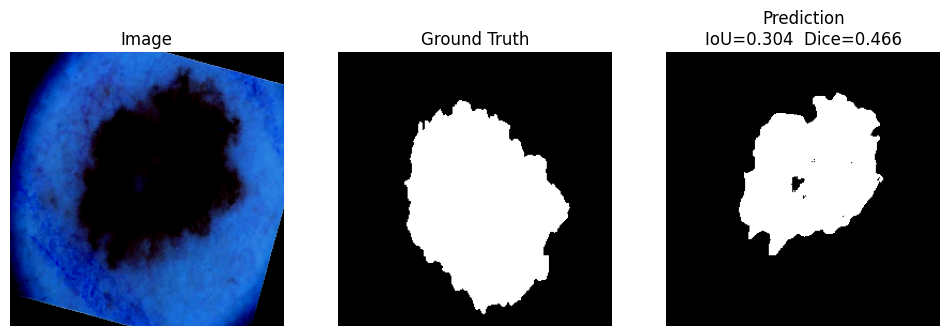

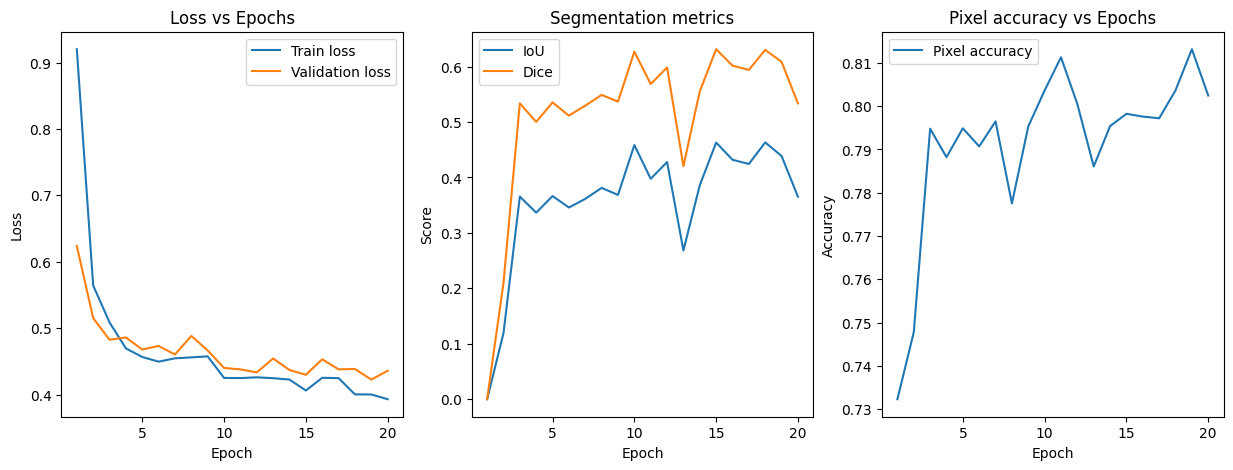

In [ ]:
import matplotlib.pyplot as plt

model.eval()

image, mask = test_dataset[0]

image = image.to(device)

with torch.no_grad():

    pred = model(image.unsqueeze(0))
    pred = torch.sigmoid(pred)

    pred = pred.squeeze().cpu()
    pred_bin = (pred > 0.5).float()

# calcul métriques pour cette image
iou = iou_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
dice = dice_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()

plt.figure(figsize=(12,4))

# Image
plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image.cpu().permute(1,2,0))
plt.axis("off")

# Mask
plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.title(f"Prediction\nIoU={iou:.3f}  Dice={dice:.3f}")
plt.imshow(pred_bin, cmap="gray")
plt.axis("off")


epochs_range = range(1, epochs + 1)

plt.figure(figsize=(15,5))

################################
# LOSS
################################

plt.subplot(1,3,1)
plt.plot(epochs_range, train_losses, label="Train loss")
plt.plot(epochs_range, val_losses, label="Validation loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

################################
# IoU + Dice
################################

plt.subplot(1,3,2)
plt.plot(epochs_range, iou_scores, label="IoU")
plt.plot(epochs_range, dice_scores, label="Dice")
plt.title("Segmentation metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

################################
# Pixel accuracy
################################

plt.subplot(1,3,3)
plt.plot(epochs_range, acc_scores, label="Pixel accuracy")
plt.title("Pixel accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()